# Natural Language Processing for Stay Play Summary Log

#### Instal Packages

In [1]:
# Install required packages
!pip install python-docx
!pip install spacy
!pip install wordcloud
!pip install matplotlib
!pip install pandas
!pip install nltk
!pip install textblob
!pip install scikit-learn
!pip install pyLDAvis
!pip install numpy
!pip install keybert

# Download spaCy English model
!python -m spacy download en_core_web_sm

# Download required NLTK data
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 3.0 MB/s eta 0:00:05
     --- ------------------------------------ 1.0/12.8 MB 2.6 MB/s eta 0:00:05
     ---- ----------------------------------- 1.6/12.8 MB 2.1 MB/s eta 0:00:06
     ----- ---------------------------------- 1.8/12.8 MB 2.0 MB/s eta 0:00:06
     ------ --------------------------------- 2.1/12.8 MB 1.8 MB/s eta 0:00:06
     ------- -------------------------------- 2.4/12.8 MB 1.6 MB/s eta 0:00:07
     -------- ------------------------------- 2.6/12.8 MB 1.7 MB/s eta 0:00:07
     --------- ------------------------------ 3.1/12.8 MB 1.7 MB/s eta 0:00:06
     ---------- ----------------------------- 3.4/12.8 MB 1.7 MB/s eta 0:00:06
     ------------- -------------------------- 4.2/12.8 MB 1.9 MB/s eta 0:00:05
     --------------- ------------------------ 5.0/12.8 MB 2.0 MB/s

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nelof\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nelof\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nelof\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Import Libraries

In [2]:
# ── Core document and data handling ──────────────────────────────────────────
from docx import Document
import pandas as pd
import numpy as np
from collections import Counter
import re
import string

# ── NLP — NLTK ───────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# ── NLP — spaCy ──────────────────────────────────────────────────────────────
import spacy

# ── Sentiment analysis ────────────────────────────────────────────────────────
from textblob import TextBlob

# ── Keyword extraction ────────────────────────────────────────────────────────
from keybert import KeyBERT

# ── Topic modelling — sklearn ─────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# ── Interactive LDA visualisation ─────────────────────────────────────────────
import pyLDAvis
import pyLDAvis.lda_model

# ── Visualisation ─────────────────────────────────────────────────────────────
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch


#### Upload session summary document

In [3]:
df = Document("stay_play.docx")

In [4]:

df = [p.text for p in df.paragraphs]
print(df[:5])  # show first 5 paragraphs


['Stay and Play Session Summary', '', '19/08/2025', 'At 10:00 AM, Coordinator Anthony prepared the venue by cleaning the space, arranging toys, and opening the Stay and Play session. Parents arrived with their children, who engaged in play under parental supervision. As the children explored and interacted with the toys, parents had the opportunity to chat and connect while keeping a close eye on their little ones.', 'Nursery rhyme music played in the background throughout the event, offering the children a choice of dance, sing-along, play, or interact with toys.']


In [5]:
print(type(df))


<class 'list'>


## Clean and Preprocess the Text

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re

In [7]:

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nelof\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nelof\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
# 1. Lowercase the text
df = [para.lower() for para in df]



In [9]:
# 2. Remove punctuation

df = [re.sub(r'[^\w\s]', '', text) for text in df]



In [10]:
# 3. In Natural Language Processing(NLP), tokenization is the first step — it involves breaking down text into smaller units called tokens, such as words, phrases, or symbols.

from nltk.tokenize import sent_tokenize

In [11]:
 paragraphs = df

In [12]:
# Tokenize each paragraph into sentences
all_sentences = []
for para in paragraphs:
    all_sentences.extend(sent_tokenize(para))
print(all_sentences)


['stay and play session summary', '19082025', 'at 1000 am coordinator anthony prepared the venue by cleaning the space arranging toys and opening the stay and play session parents arrived with their children who engaged in play under parental supervision as the children explored and interacted with the toys parents had the opportunity to chat and connect while keeping a close eye on their little ones', 'nursery rhyme music played in the background throughout the event offering the children a choice of dance singalong play or interact with toys', 'during the session the coordinator discussed plans with parents to develop the weekly stay and play into a more structured programme including dedicated nursery rhyme time storytime and a subsidised lunch offered on a donation basis to support programme planning throughout the event anthony maintained oversight of all activities ensuring a safe engaging and welcoming environment for everyone', '26082025', 'at 1000 am coordinator anthony prepar

In [13]:
# remove stopword each paragraph

english_stopwords = set(stopwords.words('english'))

In [14]:
filtered_paragraphs = []
for para in paragraphs:
    words = word_tokenize(para)
    filtered_words = [word for word in words if word.lower() not in english_stopwords]
    filtered_para = ' '.join(filtered_words)
    filtered_paragraphs.append(filtered_para)

print(filtered_paragraphs)



['stay play session summary', '', '19082025', '1000 coordinator anthony prepared venue cleaning space arranging toys opening stay play session parents arrived children engaged play parental supervision children explored interacted toys parents opportunity chat connect keeping close eye little ones', 'nursery rhyme music played background throughout event offering children choice dance singalong play interact toys', 'session coordinator discussed plans parents develop weekly stay play structured programme including dedicated nursery rhyme time storytime subsidised lunch offered donation basis support programme planning throughout event anthony maintained oversight activities ensuring safe engaging welcoming environment everyone', '', '26082025', '1000 coordinator anthony prepared venue cleaning arranging toys opening stay play session parents arrived children engaged play parents supervision children explored interacted toys parents opportunity chat connect keeping eye little ones', 'nu

In [15]:
# Download English model
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [16]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")

In [17]:
from docx import Document

docx_file = Document("stay_play.docx")

text = "\n".join([para.text for para in docx_file.paragraphs])

In [18]:


# Process text
doc = nlp(text)

# STEP 1: Print detected PERSON names
detected_names = []

for ent in doc.ents:
    if ent.label_ == "PERSON":
        detected_names.append(ent.text)

print("Detected PERSON names:")
print(detected_names)

Detected PERSON names:
['Anthony', 'Stay', 'Anthony', 'Anthony', 'Anthony', 'Anthony', '02/09/2025', 'Anthony', 'Anthony', 'Jackie', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Lunch', 'Anthony', 'Diane', 'Coordinator Anthony', 'Anthony', 'Coordinator Anthony', 'Coordinator Diane', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Lunch', 'Anthony', 'Anthony', 'Anthony', 'Anthony', 'Coordinator Anthony', 'Sarah', 'Sarah', 'Anthony', 'Anthony', 'Martin', 'Diane', 'Coordinator Anthony', 'Sarah', 'Sarah', 'Bunny\nRow', 'Anthony', 'Anthony', 'Anthony', 'Sarah', 'Anthony', 'Anthony', 'Sarah', 'Sarah', 'Sarah', 'Sarah', 'Bunny\nItsy Bitsy Spider\nRow', 'Anthony', 'Anthony', 'Sarah', 'Anthony', 'Sarah', 'Anthony', 'Sarah']


In [19]:
# Add manually detected names
names_to_remove = ['Anthony', 'Sarah', 'Diane', 'Martin']

clean_text = text

for name in names_to_remove:
    pattern = r'\b' + re.escape(name) + r'\b'
    clean_text = re.sub(pattern, '', clean_text)

# Remove extra spaces
clean_text = re.sub(r'\s+', ' ', clean_text).strip()

print(clean_text)

Stay and Play Session Summary 19/08/2025 At 10:00 AM, Coordinator prepared the venue by cleaning the space, arranging toys, and opening the Stay and Play session. Parents arrived with their children, who engaged in play under parental supervision. As the children explored and interacted with the toys, parents had the opportunity to chat and connect while keeping a close eye on their little ones. Nursery rhyme music played in the background throughout the event, offering the children a choice of dance, sing-along, play, or interact with toys. During the session, the coordinator discussed plans with parents to develop the weekly Stay and Play into a more structured programme, including dedicated nursery rhyme time, storytime, and a subsidised lunch offered on a donation basis to support programme planning. Throughout the event, maintained oversight of all activities, ensuring a safe, engaging, and welcoming environment for everyone. 26/08/2025 At 10:00 AM, Coordinator prepared the venue 

In [20]:
# ── Session builder ─────────────────────────────────────────────────────────
# Splits stay_play.docx into per-session dicts: {'date': str, 'text': str}
# Defines `sessions` — required by every per-session analysis in this notebook:
# lemmatisation, POS, themes heatmap, sentiment scorer, KeyBERT, LDA corpus,
# and the master table.

import re
from docx import Document as _Doc

_sb_doc   = _Doc('stay_play.docx')
_sb_paras = [p.text.strip() for p in _sb_doc.paragraphs if p.text.strip()]
_sb_dpat  = re.compile(r'^(\d{1,2}/\d{1,2}/\d{4})$')

sessions, _sb_date, _sb_lines = [], None, []
for _p in _sb_paras:
    if _sb_dpat.match(_p):
        if _sb_date and _sb_lines:
            sessions.append({'date': _sb_date, 'text': ' '.join(_sb_lines)})
        _sb_date, _sb_lines = _p, []
    elif _sb_date:
        _sb_lines.append(_p)
if _sb_date and _sb_lines:
    sessions.append({'date': _sb_date, 'text': ' '.join(_sb_lines)})

print(f'Sessions detected: {len(sessions)}')
print(f'First: {sessions[0]["date"]}  |  Last: {sessions[-1]["date"]}')


Sessions detected: 16
First: 19/08/2025  |  Last: 16/12/2025


# Word Frequency Analysis

In [21]:
# Fix: tokenise before counting
words = word_tokenize(clean_text)
filtered_words = [w for w in words if w.isalpha() and w not in english_stopwords]
word_freq = Counter(filtered_words)


In [22]:
print("Word Frequency:")
for word, freq in word_freq.items():
    print(f"{word}: {freq}")


Word Frequency:
Stay: 20
Play: 20
Session: 1
Summary: 1
At: 19
AM: 23
Coordinator: 16
prepared: 18
venue: 18
cleaning: 17
space: 1
arranging: 14
toys: 40
opening: 17
session: 45
Parents: 19
arrived: 18
children: 70
engaged: 18
play: 36
parental: 1
supervision: 19
As: 10
explored: 11
interacted: 13
parents: 61
opportunity: 12
chat: 12
connect: 12
keeping: 11
close: 2
eye: 11
little: 14
ones: 14
Nursery: 5
rhyme: 9
music: 5
played: 6
background: 5
throughout: 8
event: 12
offering: 8
choice: 8
dance: 5
interact: 5
During: 7
coordinator: 5
discussed: 2
plans: 1
develop: 1
weekly: 1
structured: 1
programme: 2
including: 2
dedicated: 1
nursery: 9
time: 4
storytime: 1
subsidised: 1
lunch: 22
offered: 1
donation: 1
basis: 1
support: 2
planning: 1
Throughout: 9
maintained: 10
oversight: 11
activities: 22
ensuring: 15
safe: 16
engaging: 9
welcoming: 16
environment: 17
everyone: 12
served: 16
wraps: 1
PM: 22
enjoying: 4
meal: 6
Jackie: 1
potatoes: 4
Later: 4
chicken: 3
pizza: 6
toasted: 2
bread: 

In [23]:

df = pd.DataFrame(word_freq.items(), columns = ['Word', 'Frequency']).sort_values(by='Frequency', ascending = False)
print(df.head(10))                                                                                  

           Word  Frequency
17     children         70
25      parents         61
14      session         45
12         toys         40
19         play         36
115         The         25
5            AM         23
77           PM         22
68   activities         22
59        lunch         22


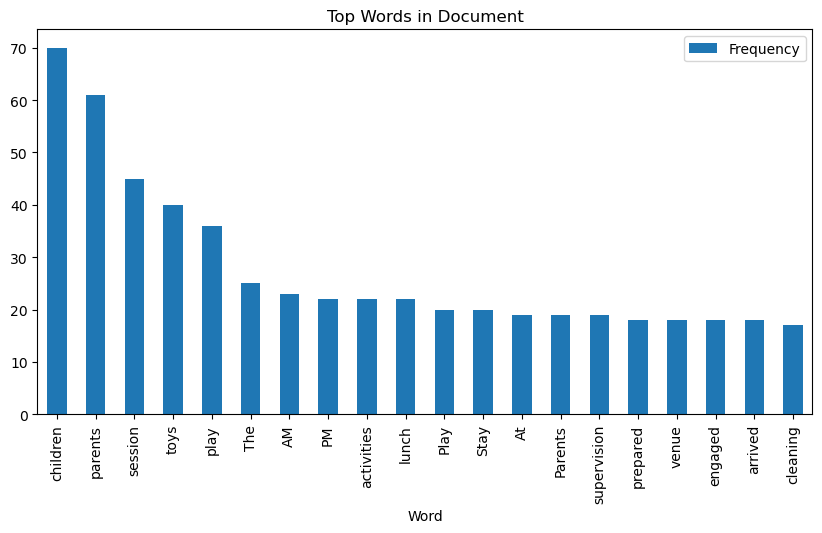

In [24]:
top_n = 20
df.head(top_n).plot(kind='bar', x='Word', y='Frequency', figsize=(10,5))
plt.title('Top Words in Document')
plt.show()

## Lemmatisation
Reduces inflected word forms to their dictionary base so that *played*, *playing* and *plays* all count as *play*. spaCy is already loaded — we re-process `clean_text` and compare the vocabulary size before and after.

In [25]:
nlp.max_length = max(nlp.max_length, len(clean_text) + 1000)
lemma_doc = nlp(clean_text)

LEMMA_SKIP = set(stopwords.words('english')) | {
    'stay', 'play', 'session', 'week', 'summary', 'coordinator', 'log',
}

lemmatised_tokens = [
    token.lemma_.lower()
    for token in lemma_doc
    if  token.is_alpha
    and not token.is_stop
    and len(token.text) > 2
    and token.lemma_.lower() not in LEMMA_SKIP
]

lemma_freq = Counter(lemmatised_tokens)
lemma_df   = pd.DataFrame(lemma_freq.most_common(30), columns=['lemma', 'count'])

print(f'Unique raw tokens : {len(word_freq)}')
print(f'Unique lemmas     : {len(lemma_freq)}')
print(f'Vocabulary reduction: {100*(1 - len(lemma_freq)/len(word_freq)):.1f}%')
print()
print(lemma_df.head(20).to_string(index=False))


Unique raw tokens : 291
Unique lemmas     : 218
Vocabulary reduction: 25.1%

      lemma  count
     parent     80
      child     70
        toy     40
      lunch     24
    prepare     23
   activity     22
     engage     20
supervision     19
   interact     19
      venue     18
      clean     18
       open     18
     arrive     18
       chat     17
    connect     17
environment     17
      rhyme     16
     ensure     16
       safe     16
      enjoy     16


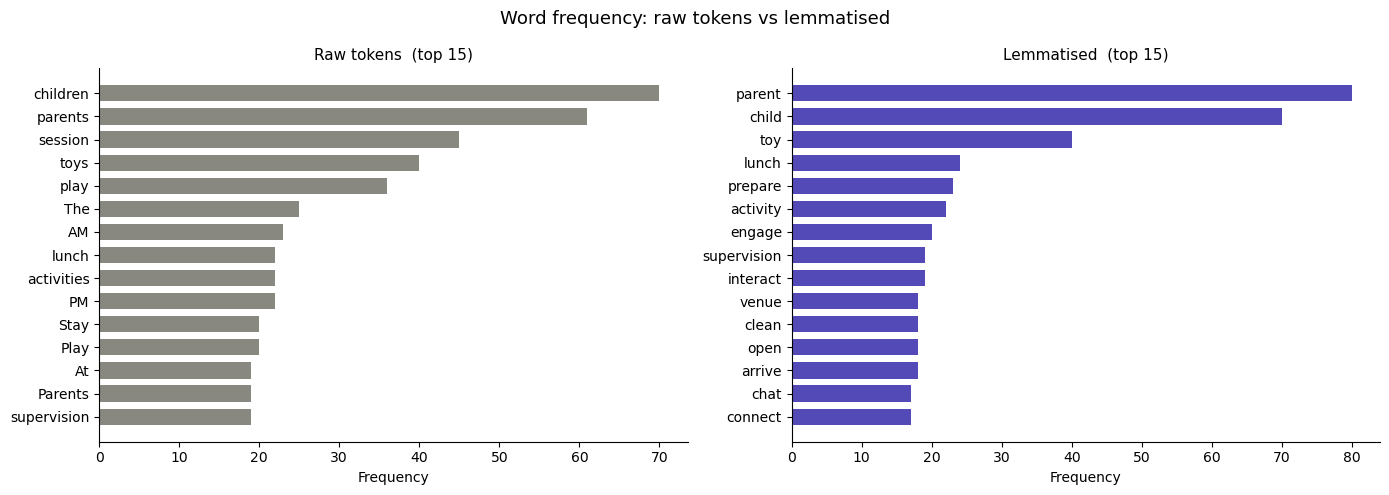

Saved lemma_comparison.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word frequency: raw tokens vs lemmatised', fontsize=13)

top_raw   = pd.DataFrame(word_freq.most_common(15), columns=['word', 'count'])
top_lemma = lemma_df.head(15)

for ax, data, colour, title in [
    (axes[0], top_raw,   '#888780', 'Raw tokens  (top 15)'),
    (axes[1], top_lemma, '#534AB7', 'Lemmatised  (top 15)'),
]:
    ax.barh(data.iloc[:, 0][::-1], data.iloc[:, 1][::-1], color=colour, height=0.7)
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('lemma_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved lemma_comparison.png')


# Visualize Results
# Bar chart of top words

## N-gram analysis (bigrams & trigrams)
Single-word counts miss meaningful phrases like *'group play'*, *'story time'* and *'jacket potato'*. Bigrams (2-word) and trigrams (3-word) surface these compound expressions.

In [27]:
# Use per-session corpus if available; else fall back to whole document
try:
    ngram_corpus = raw_sessions
except NameError:
    ngram_corpus = [clean_text]

def get_top_ngrams(corpus, n, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english',
                          min_df=1, max_features=400).fit(corpus)
    counts = vec.transform(corpus).toarray().sum(axis=0)
    ranked = sorted(zip(vec.get_feature_names_out(), counts),
                    key=lambda x: x[1], reverse=True)[:top_k]
    return pd.DataFrame(ranked, columns=['ngram', 'count'])

bigrams  = get_top_ngrams(ngram_corpus, 2, top_k=20)
trigrams = get_top_ngrams(ngram_corpus, 3, top_k=15)

print('=== Top 20 bigrams ===')
print(bigrams.to_string(index=False))
print()
print('=== Top 15 trigrams ===')
print(trigrams.to_string(index=False))


=== Top 20 bigrams ===
                ngram  count
            stay play     20
                10 00     18
     arrived children     18
         play parents     18
     children engaged     17
         opening stay     17
  parents supervision     17
         toys opening     17
       venue cleaning     17
welcoming environment     16
        ensuring safe     15
      parents arrived     15
       arranging toys     14
          little ones     14
         toys parents     14
   cleaning arranging     13
      interacted toys     13
     parents children     13
       00 coordinator     12
         chat connect     12

=== Top 15 trigrams ===
                   ngram  count
arrived children engaged     17
       opening stay play     17
       toys opening stay     17
parents arrived children     15
  arranging toys opening     14
 cleaning arranging toys     13
venue cleaning arranging     13
       10 00 coordinator     12
opportunity chat connect     12
parents opportunity cha

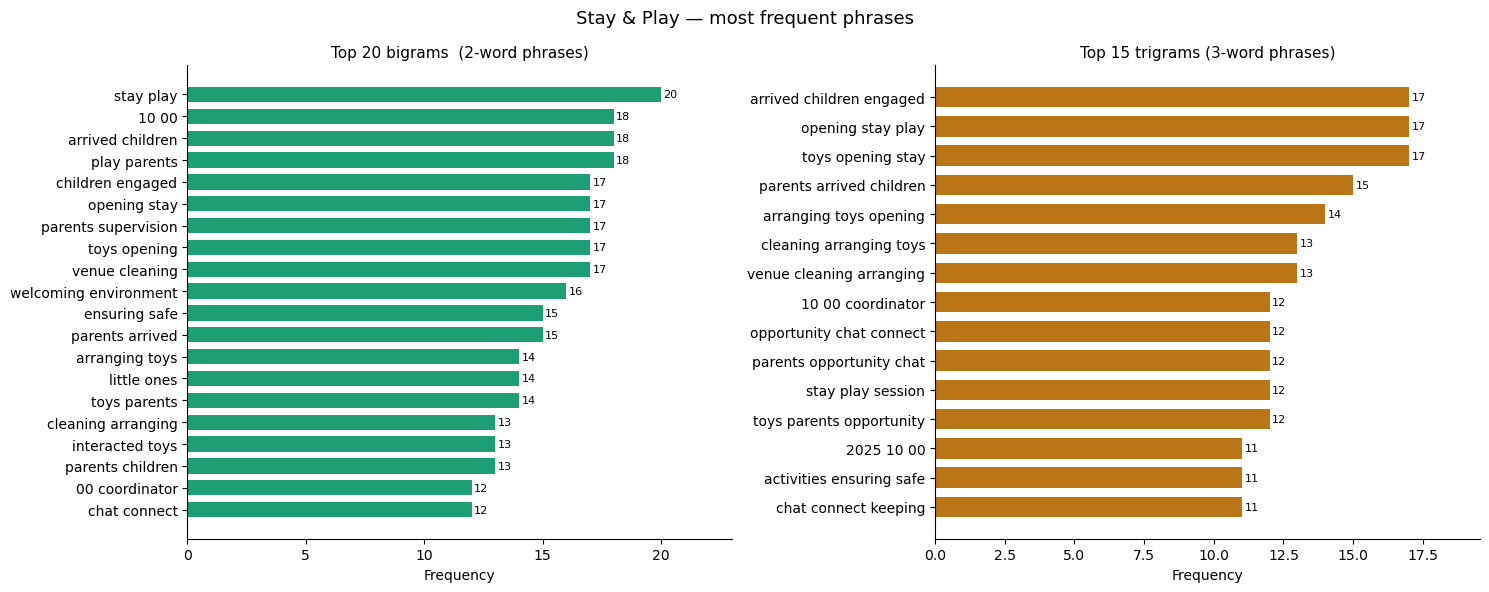

Saved ngram_analysis.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Stay & Play — most frequent phrases', fontsize=13)

for ax, data, colour, title in [
    (axes[0], bigrams,  '#1D9E75', 'Top 20 bigrams  (2-word phrases)'),
    (axes[1], trigrams, '#BA7517', 'Top 15 trigrams (3-word phrases)'),
]:
    ax.barh(data['ngram'][::-1], data['count'][::-1], color=colour, height=0.7)
    for i, count in enumerate(data['count'][::-1]):
        ax.text(count + 0.1, i, str(count), va='center', fontsize=8)
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, data['count'].max() * 1.15)

plt.tight_layout()
plt.savefig('ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ngram_analysis.png')


## SESSION SUMMARY WORDCLOUD

C:\Users\nelof\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(x, subok=True, copy=copy)


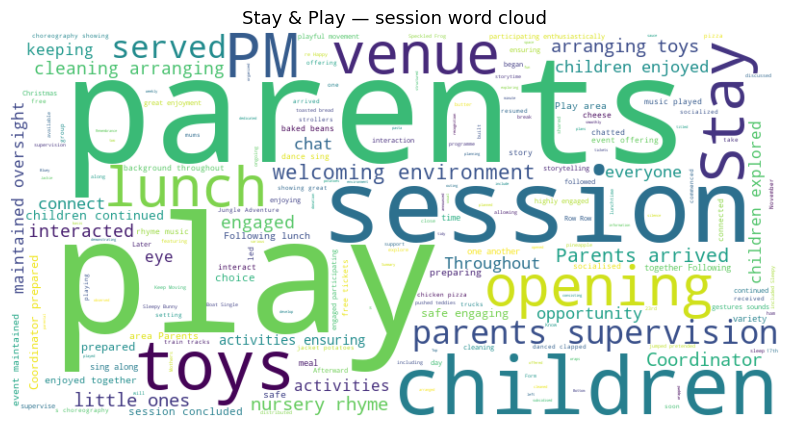

Saved word_cloud.png


In [29]:
wordcloud = WordCloud(
    width=800, height=400, background_color='white'
).generate(' '.join(clean_text.split()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Stay & Play — session word cloud', fontsize=13)
plt.savefig('word_cloud.png', dpi=300, bbox_inches='tight')  # relative path — works on any machine
plt.show()
print('Saved word_cloud.png')


# Part-of-Speech (POS) Tagging Analysis
Extracts the most frequent **verbs** (what happens), **nouns** (people, objects, concepts) and **adjectives** (descriptors) across all session summaries using spaCy. This gives a richer picture of programme activity than word frequency alone.

In [30]:
from collections import Counter
import spacy

# ── Reuse the spaCy model already loaded (nlp) and clean_text ────────────────
# If running this cell independently, uncomment the two lines below:
# nlp = spacy.load('en_core_web_sm')
# clean_text already defined in the preprocessing section above

# spaCy processes up to 1 000 000 chars by default; extend if needed
nlp.max_length = max(nlp.max_length, len(clean_text) + 1000)

doc = nlp(clean_text)

# POS tags we care about:
#   VERB  — base verbs (run, play, sing)
#   NOUN  — common nouns (children, lunch, session)
#   PROPN — proper nouns (Kipper, Bluey) — merged into NOUN bucket
#   ADJ   — adjectives (safe, engaging, welcoming)

# Domain stopwords — these are structurally common but carry no programme insight
SKIP_WORDS = {
    # generic session admin language
    'stay', 'play', 'session', 'sessions', 'week', 'summary', 'log',
    # coordinators already stripped by NER, but catch lemma forms
    'coordinator', 'coordinators',
    # pronouns that slip through as NOUN
    'it', 'they', 'them', 'their', 'we', 'our', 'who',
    # generic verbs with no programme meaning
    'be', 'have', 'do', 'say', 'get', 'go', 'come', 'make', 'use',
}

verbs, nouns, adjectives = Counter(), Counter(), Counter()

for token in doc:
    # Skip punctuation, spaces, numbers, stopwords, short tokens
    if token.is_stop or token.is_punct or token.is_space:
        continue
    if not token.is_alpha or len(token.text) < 3:
        continue

    lemma = token.lemma_.lower()
    if lemma in SKIP_WORDS:
        continue

    if token.pos_ == 'VERB':
        verbs[lemma] += 1
    elif token.pos_ in ('NOUN', 'PROPN'):
        nouns[lemma] += 1
    elif token.pos_ == 'ADJ':
        adjectives[lemma] += 1

TOP_N = 20
top_verbs = verbs.most_common(TOP_N)
top_nouns = nouns.most_common(TOP_N)
top_adjs  = adjectives.most_common(TOP_N)

print(f"Unique verbs found:      {len(verbs)}")
print(f"Unique nouns found:      {len(nouns)}")
print(f"Unique adjectives found: {len(adjectives)}")
print()
print(f"Top {TOP_N} verbs:     ", [w for w,_ in top_verbs])
print(f"Top {TOP_N} nouns:     ", [w for w,_ in top_nouns])
print(f"Top {TOP_N} adjectives:", [w for w,_ in top_adjs])


Unique verbs found:      73
Unique nouns found:      113
Unique adjectives found: 30

Top 20 verbs:      ['prepare', 'engage', 'interact', 'clean', 'open', 'arrive', 'chat', 'connect', 'ensure', 'enjoy', 'arrange', 'continue', 'explore', 'serve', 'keep', 'maintain', 'follow', 'offer', 'welcome', 'conclude']
Top 20 nouns:      ['parent', 'child', 'toy', 'lunch', 'activity', 'supervision', 'venue', 'environment', 'rhyme', 'one', 'nursery', 'opportunity', 'event', 'eye', 'oversight', 'choice', 'area', 'sing', 'time', 'meal']
Top 20 adjectives: ['safe', 'little', 'engaging', 'free', 'welcoming', 'baked', 'playful', 'great', 'close', 'served', 'ongoing', 'available', 'happy', 'prepared', 'parental', 'weekly', 'structured', 'dedicated', 'break', 'engaged']


In [31]:
import pandas as pd

# ── Build tidy DataFrames for each POS category ───────────────────────────────
verbs_df = pd.DataFrame(top_verbs,  columns=['word', 'count']).assign(pos='Verb')
nouns_df = pd.DataFrame(top_nouns,  columns=['word', 'count']).assign(pos='Noun')
adjs_df  = pd.DataFrame(top_adjs,   columns=['word', 'count']).assign(pos='Adjective')

pos_df = pd.concat([verbs_df, nouns_df, adjs_df], ignore_index=True)

print("=== Top verbs ===")
print(verbs_df[['word','count']].to_string(index=False))
print()
print("=== Top nouns ===")
print(nouns_df[['word','count']].to_string(index=False))
print()
print("=== Top adjectives ===")
print(adjs_df[['word','count']].to_string(index=False))


=== Top verbs ===
    word  count
 prepare     23
  engage     20
interact     19
   clean     18
    open     18
  arrive     18
    chat     17
 connect     17
  ensure     16
   enjoy     16
 arrange     15
continue     15
 explore     14
   serve     14
    keep     11
maintain     11
  follow     11
   offer      9
 welcome      9
conclude      8

=== Top nouns ===
       word  count
     parent     80
      child     70
        toy     40
      lunch     24
   activity     22
supervision     19
      venue     18
environment     17
      rhyme     16
        one     14
    nursery     14
opportunity     12
      event     12
        eye     11
  oversight     11
     choice      8
       area      7
       sing      6
       time      6
       meal      6

=== Top adjectives ===
      word  count
      safe     16
    little     14
  engaging      9
      free      8
 welcoming      7
     baked      5
   playful      4
     great      4
     close      2
    served      2
   ong

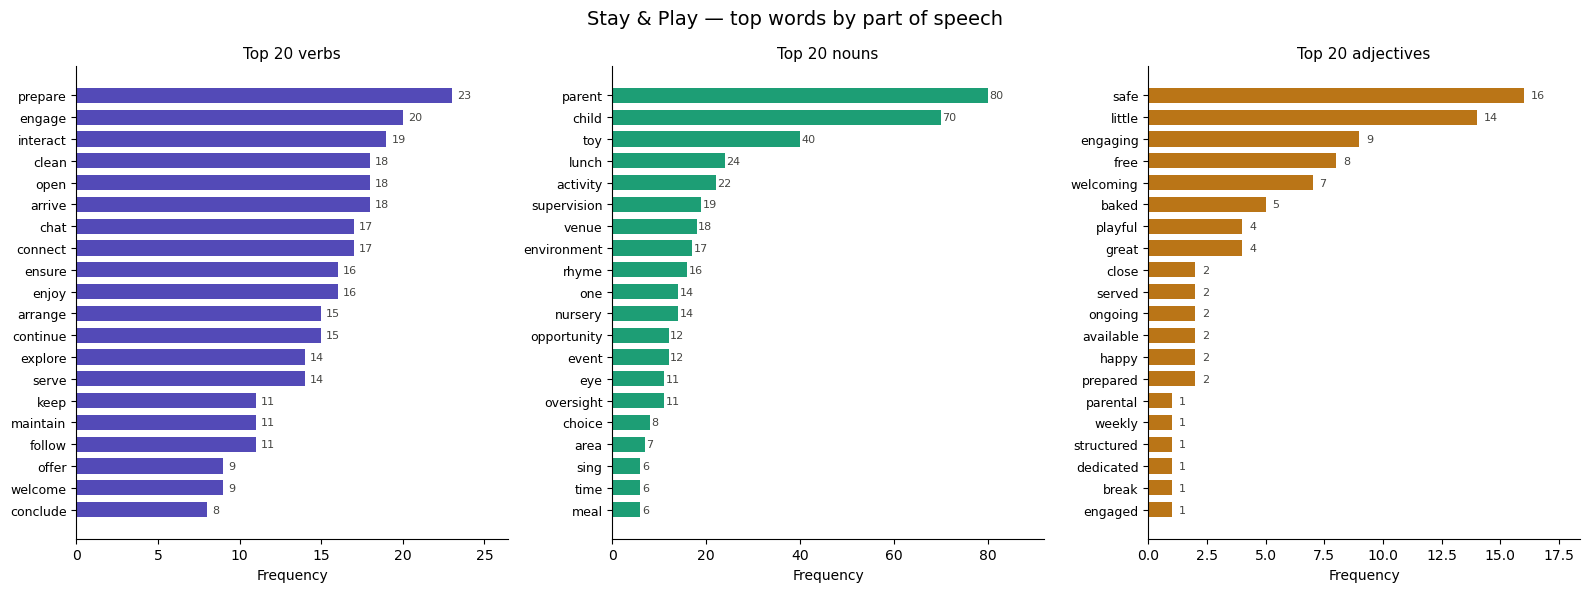

Saved pos_top_words.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Palette — purple = verbs, teal = nouns, amber = adjectives
COLOURS = {'Verb': '#534AB7', 'Noun': '#1D9E75', 'Adjective': '#BA7517'}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Stay & Play — top words by part of speech', fontsize=14)

for ax, (df_part, label) in zip(axes, [
    (verbs_df, 'Verb'),
    (nouns_df, 'Noun'),
    (adjs_df,  'Adjective'),
]):
    colour = COLOURS[label]
    ax.barh(
        df_part['word'][::-1],   # reverse so highest count is at top
        df_part['count'][::-1],
        color=colour, height=0.7
    )
    # Value labels inside/beside each bar
    for i, (word, count) in enumerate(zip(
            df_part['word'][::-1], df_part['count'][::-1])):
        ax.text(count + 0.3, i, str(count), va='center', fontsize=8, color='#444441')

    ax.set_title(f'Top {TOP_N} {label.lower()}s', fontsize=11)
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top','right']].set_visible(False)
    # Leave a little right margin for count labels
    ax.set_xlim(0, df_part['count'].max() * 1.15)

plt.tight_layout()
plt.savefig('pos_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pos_top_words.png")


C:\Users\nelof\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(x, subok=True, copy=copy)
C:\Users\nelof\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(x, subok=True, copy=copy)
C:\Users\nelof\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(x, subok=True, copy=copy)


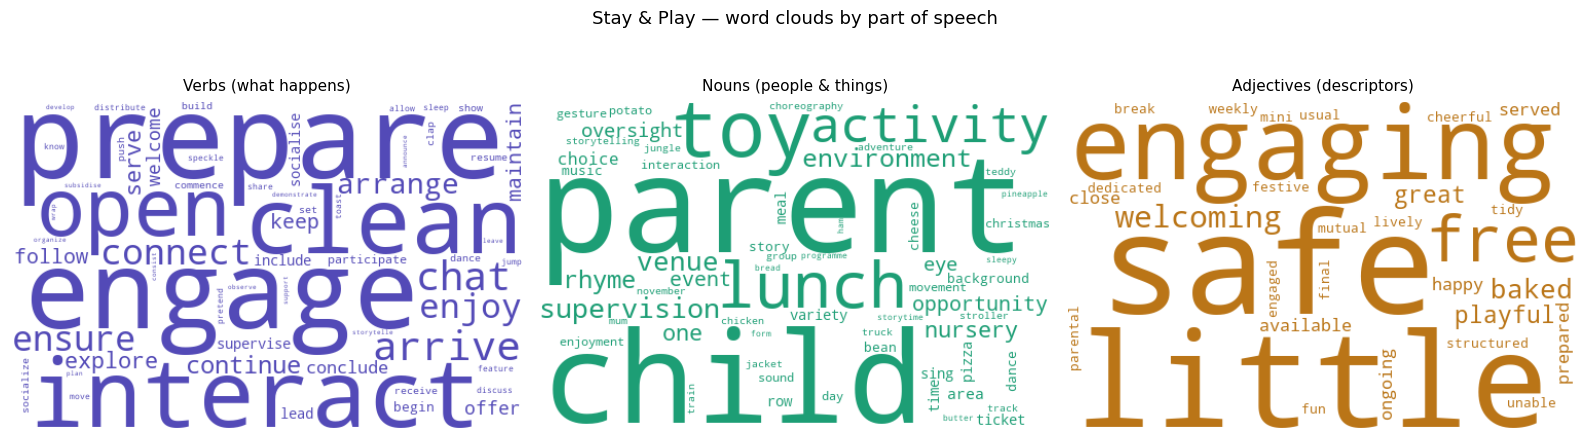

Saved pos_wordclouds.png


In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ── One word cloud per POS category ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stay & Play — word clouds by part of speech', fontsize=13)

wc_configs = [
    (verbs,      'Verbs (what happens)',       '#534AB7'),
    (nouns,      'Nouns (people & things)',     '#1D9E75'),
    (adjectives, 'Adjectives (descriptors)',    '#BA7517'),
]

for ax, (freq_counter, title, colour) in zip(axes, wc_configs):
    wc = WordCloud(
        width=500, height=320,
        background_color='white',
        color_func=lambda *args, **kwargs: colour,
        max_words=60,
        prefer_horizontal=0.85,
    ).generate_from_frequencies(freq_counter)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=11, pad=8)

plt.tight_layout()
plt.savefig('pos_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pos_wordclouds.png")


      date  verb_pct  noun_pct  adj_pct
19/08/2025      29.6      60.5      9.9
26/08/2025      31.2      64.1      4.7
02/09/2025      30.8      64.6      4.6
09/09/2025      31.5      63.0      5.6
16/09/2025      31.3      64.2      4.5
23/09/2025      35.6      57.6      6.8
30/09/2025      31.2      59.4      9.4
07/10/2025      30.4      63.3      6.3
14/10/2025      30.3      59.6     10.1
21/10/2025      31.4      56.9     11.8
28/10/2025      27.6      61.8     10.5
04/11/2025      29.3      61.0      9.8
11/11/2025      32.4      59.5      8.1
19/11/2025      34.5      62.1      3.4
25/11/2025      34.0      60.8      5.2
16/12/2025      26.4      63.7      9.9


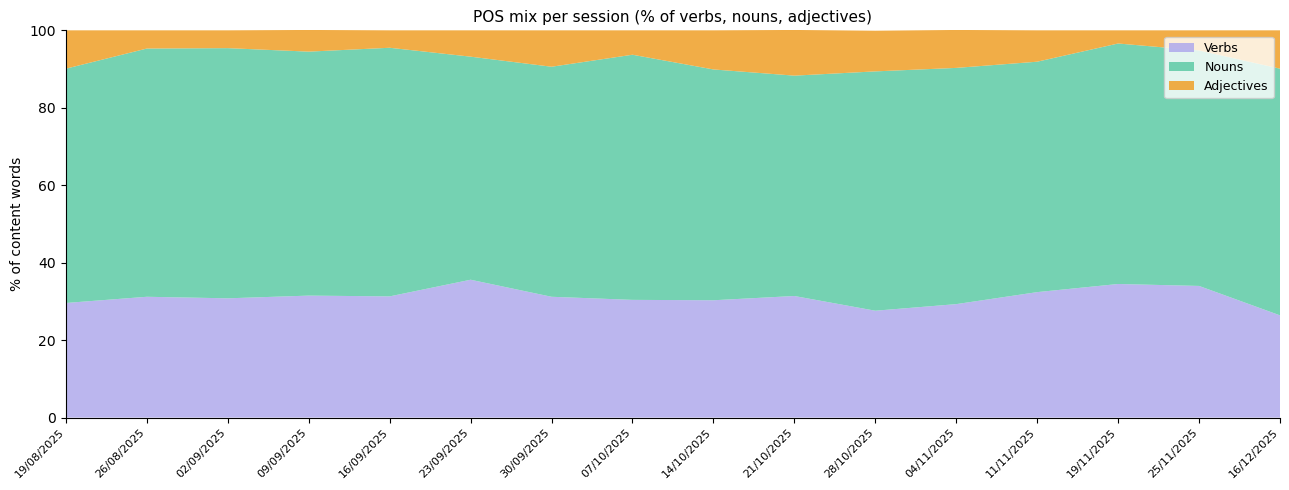

Saved pos_session_profile.png
Saved pos_profile.csv


In [34]:
import re, spacy, pandas as pd
import matplotlib.pyplot as plt

# ── Build a POS profile for each session ─────────────────────────────────────
# Reuses the 'sessions' list built in the sentiment section.
# If running independently, re-parse the docx with the date-splitting logic above.

session_pos_records = []

for s in sessions:
    sdoc = nlp(s['text'])
    sv = sn = sa = 0
    for token in sdoc:
        if token.is_stop or token.is_punct or token.is_space or not token.is_alpha:
            continue
        if token.pos_ == 'VERB':             sv += 1
        elif token.pos_ in ('NOUN','PROPN'): sn += 1
        elif token.pos_ == 'ADJ':            sa += 1

    total = sv + sn + sa or 1   # avoid div-by-zero
    session_pos_records.append({
        'date':       s['date'],
        'verb_pct':   round(sv / total * 100, 1),
        'noun_pct':   round(sn / total * 100, 1),
        'adj_pct':    round(sa / total * 100, 1),
        'verb_count': sv,
        'noun_count': sn,
        'adj_count':  sa,
    })

pos_profile_df = pd.DataFrame(session_pos_records)
pos_profile_df['date_parsed'] = pd.to_datetime(
    pos_profile_df['date'], dayfirst=True, errors='coerce'
)
pos_profile_df = pos_profile_df.sort_values('date_parsed').reset_index(drop=True)

print(pos_profile_df[['date','verb_pct','noun_pct','adj_pct']].to_string(index=False))

# ── Stacked area chart — POS mix across sessions ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

x = range(len(pos_profile_df))
ax.stackplot(
    x,
    pos_profile_df['verb_pct'],
    pos_profile_df['noun_pct'],
    pos_profile_df['adj_pct'],
    labels=['Verbs', 'Nouns', 'Adjectives'],
    colors=['#AFA9EC', '#5DCAA5', '#EF9F27'],
    alpha=0.85
)

ax.set_xticks(list(x))
ax.set_xticklabels(pos_profile_df['date'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('% of content words')
ax.set_title('POS mix per session (% of verbs, nouns, adjectives)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, len(pos_profile_df) - 1)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('pos_session_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pos_session_profile.png")

# Export
pos_profile_df.drop(columns='date_parsed').to_csv('pos_profile.csv', index=False)
print("Saved pos_profile.csv")


# Sentiment Analysis

In [35]:
from textblob import TextBlob
text = clean_text
blob = TextBlob(text)

In [36]:
print(blob.sentiment)

Sentiment(polarity=0.24212278630460454, subjectivity=0.5425889413616688)


In [37]:
sentiment = blob.sentiment

In [38]:
print(f"Polarity: {sentiment.polarity}, Subjectivity: {sentiment.subjectivity}")

Polarity: 0.24212278630460454, Subjectivity: 0.5425889413616688


## Per-session sentiment analysis over time

In [39]:
import re
from docx import Document
from textblob import TextBlob
import pandas as pd

# ── 1. Load the document ──────────────────────────────────────────────────────
docx_file = Document("stay_play.docx")
paragraphs = [p.text.strip() for p in docx_file.paragraphs if p.text.strip()]

# ── 2. Detect date lines (DD/MM/YYYY) and group paragraphs into sessions ─────
date_pattern = re.compile(r'^(\d{1,2}/\d{1,2}/\d{4})$')

sessions = []          # list of {'date': str, 'text': str}
current_date = None
current_lines = []

for para in paragraphs:
    if date_pattern.match(para):
        if current_date and current_lines:
            sessions.append({'date': current_date,
                             'text': ' '.join(current_lines)})
        current_date = para
        current_lines = []
    else:
        if current_date:
            current_lines.append(para)

# Flush the final session
if current_date and current_lines:
    sessions.append({'date': current_date, 'text': ' '.join(current_lines)})

print(f"Sessions detected: {len(sessions)}")
if sessions:
    print(f"First: {sessions[0]['date']}  |  Last: {sessions[-1]['date']}")


Sessions detected: 16
First: 19/08/2025  |  Last: 16/12/2025


In [40]:
from textblob import TextBlob
import pandas as pd

# ── 3. Run TextBlob on each session ──────────────────────────────────────────
records = []
for s in sessions:
    blob = TextBlob(s['text'])
    polarity    = round(blob.sentiment.polarity,    3)
    subjectivity = round(blob.sentiment.subjectivity, 3)

    # Classify tone: positive / neutral / negative
    if polarity > 0.1:
        tone = 'Positive'
    elif polarity < -0.05:
        tone = 'Negative'
    else:
        tone = 'Neutral'

    records.append({
        'date':          s['date'],
        'polarity':      polarity,
        'subjectivity':  subjectivity,
        'tone':          tone,
        'word_count':    len(s['text'].split())
    })

sentiment_df = pd.DataFrame(records)
sentiment_df['date_parsed'] = pd.to_datetime(
    sentiment_df['date'], dayfirst=True, errors='coerce'
)
sentiment_df = sentiment_df.sort_values('date_parsed').reset_index(drop=True)

# ── 4. Summary statistics ────────────────────────────────────────────────────
print("=== Per-session sentiment summary ===")
print(sentiment_df[['date','polarity','subjectivity','tone','word_count']].to_string(index=False))
print()
print(f"Average polarity:     {sentiment_df['polarity'].mean():.3f}")
print(f"Average subjectivity: {sentiment_df['subjectivity'].mean():.3f}")
print(f"Tone breakdown:\n{sentiment_df['tone'].value_counts().to_string()}")


=== Per-session sentiment summary ===
      date  polarity  subjectivity     tone  word_count
19/08/2025     0.303         0.550 Positive         140
26/08/2025     0.303         0.575 Positive         116
02/09/2025     0.303         0.575 Positive         117
09/09/2025     0.238         0.567 Positive          98
16/09/2025     0.102         0.542 Positive         124
23/09/2025     0.242         0.500 Positive         106
30/09/2025     0.035         0.442  Neutral         117
07/10/2025     0.163         0.360 Positive         155
14/10/2025     0.336         0.519 Positive         165
21/10/2025     0.221         0.567 Positive         102
28/10/2025     0.125         0.509 Positive         158
04/11/2025     0.247         0.556 Positive         158
11/11/2025     0.251         0.529 Positive         191
19/11/2025    -0.125         0.375 Negative          54
25/11/2025     0.358         0.581 Positive         487
16/12/2025     0.264         0.721 Positive         159

Average p

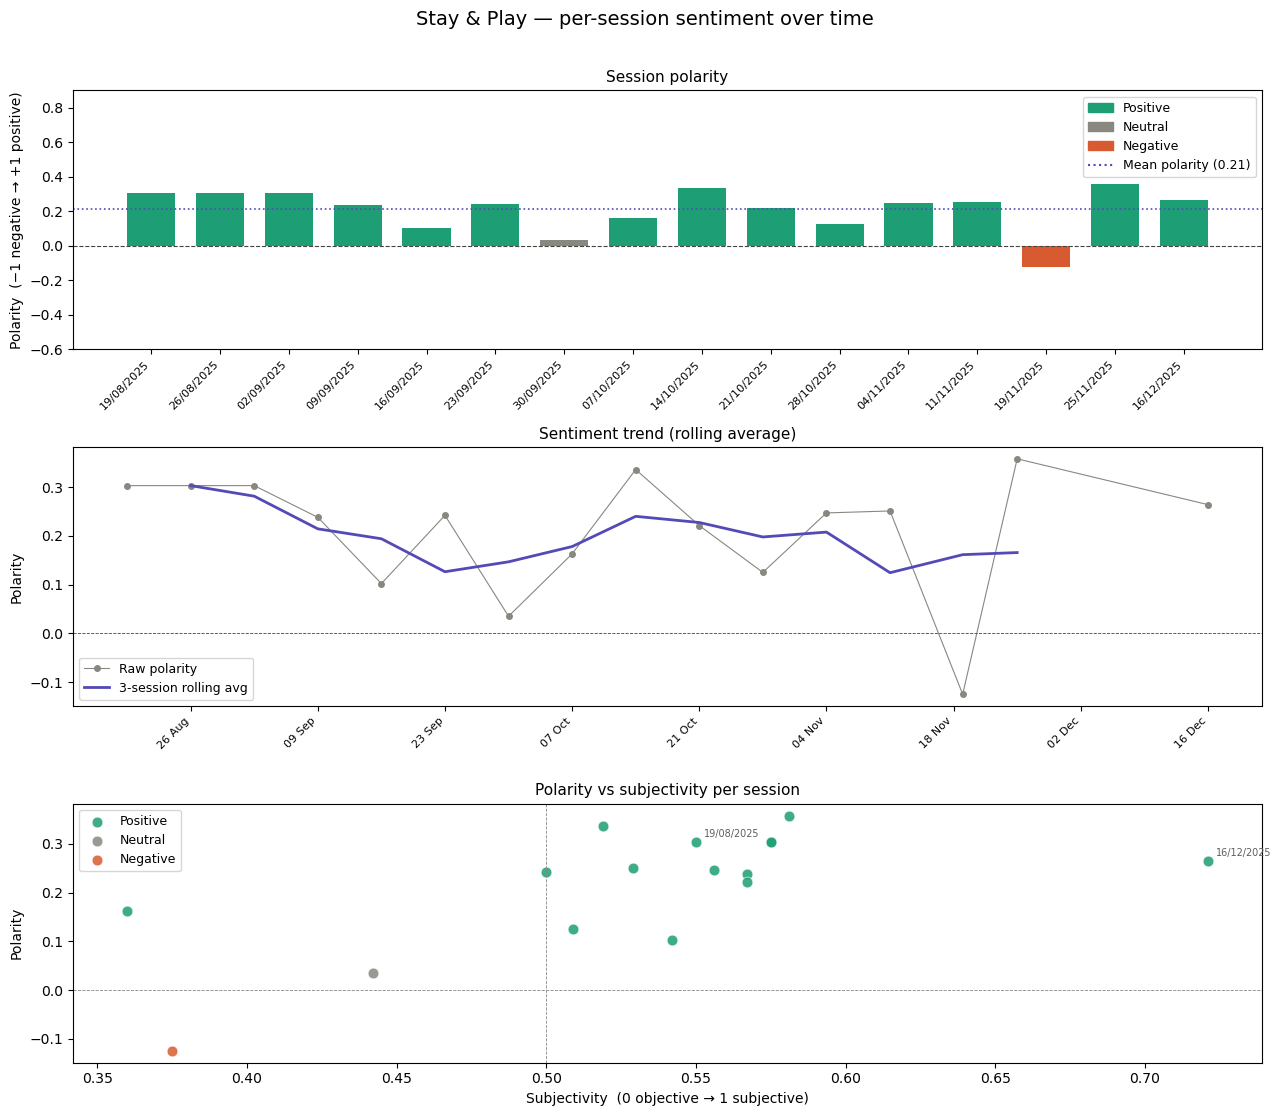

Saved sentiment_over_time.png


In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Colour map: Positive=teal, Neutral=gray, Negative=coral ──────────────────
TONE_COLOURS = {'Positive': '#1D9E75', 'Neutral': '#888780', 'Negative': '#D85A30'}
bar_colours = sentiment_df['tone'].map(TONE_COLOURS)

fig, axes = plt.subplots(3, 1, figsize=(13, 11))
fig.suptitle('Stay & Play — per-session sentiment over time', fontsize=14, y=1.01)

# ── Plot 1: Polarity bar chart (one bar per session) ─────────────────────────
ax1 = axes[0]
x = range(len(sentiment_df))
ax1.bar(x, sentiment_df['polarity'], color=bar_colours, width=0.7)
ax1.axhline(0, color='#444441', linewidth=0.8, linestyle='--')
ax1.axhline(sentiment_df['polarity'].mean(), color='#534AB7',
            linewidth=1.2, linestyle=':', label=f"Mean ({sentiment_df['polarity'].mean():.2f})")
ax1.set_xticks(list(x))
ax1.set_xticklabels(sentiment_df['date'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Polarity  (−1 negative → +1 positive)')
ax1.set_title('Session polarity', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(-0.6, 0.9)

# legend patches for tone colours
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=t) for t, c in TONE_COLOURS.items()]
ax1.legend(handles=legend_patches + [
    plt.Line2D([0],[0], color='#534AB7', linestyle=':', linewidth=1.5,
               label=f"Mean polarity ({sentiment_df['polarity'].mean():.2f})")
], fontsize=9, loc='upper right')

# ── Plot 2: Rolling-average trend line ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(sentiment_df['date_parsed'], sentiment_df['polarity'],
         marker='o', markersize=4, color='#888780', linewidth=0.8, label='Raw polarity')

window = min(3, len(sentiment_df))          # 3-session rolling average
rolling = sentiment_df['polarity'].rolling(window, center=True).mean()
ax2.plot(sentiment_df['date_parsed'], rolling,
         color='#534AB7', linewidth=2, label=f'{window}-session rolling avg')

ax2.axhline(0, color='#444441', linewidth=0.6, linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Polarity')
ax2.set_title('Sentiment trend (rolling average)', fontsize=11)
ax2.legend(fontsize=9)

# ── Plot 3: Polarity vs Subjectivity scatter ──────────────────────────────────
ax3 = axes[2]
for tone, colour in TONE_COLOURS.items():
    mask = sentiment_df['tone'] == tone
    ax3.scatter(
        sentiment_df.loc[mask, 'subjectivity'],
        sentiment_df.loc[mask, 'polarity'],
        c=colour, label=tone, s=60, alpha=0.85, edgecolors='white', linewidth=0.5
    )

# Annotate the earliest and latest sessions
for idx in [0, len(sentiment_df)-1]:
    row = sentiment_df.iloc[idx]
    ax3.annotate(row['date'],
                 xy=(row['subjectivity'], row['polarity']),
                 xytext=(6, 4), textcoords='offset points', fontsize=7, color='#5F5E5A')

ax3.axhline(0, color='#888780', linewidth=0.6, linestyle='--')
ax3.axvline(0.5, color='#888780', linewidth=0.6, linestyle='--')
ax3.set_xlabel('Subjectivity  (0 objective → 1 subjective)')
ax3.set_ylabel('Polarity')
ax3.set_title('Polarity vs subjectivity per session', fontsize=11)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sentiment_over_time.png")


In [42]:
# ── 5. Flag sessions with unusually low or high sentiment ────────────────────
# Outliers defined as polarity more than 1 std dev from the mean
mean_pol = sentiment_df['polarity'].mean()
std_pol  = sentiment_df['polarity'].std()

low_threshold  = mean_pol - std_pol
high_threshold = mean_pol + std_pol

low_sessions  = sentiment_df[sentiment_df['polarity'] < low_threshold]
high_sessions = sentiment_df[sentiment_df['polarity'] > high_threshold]

print(f"Mean polarity: {mean_pol:.3f}  |  Std dev: {std_pol:.3f}")
print(f"Thresholds  — low: {low_threshold:.3f}  |  high: {high_threshold:.3f}")
print()
print("=== Sessions with notably LOW sentiment (may need review) ===")
if low_sessions.empty:
    print("None found below threshold.")
else:
    print(low_sessions[['date','polarity','tone','word_count']].to_string(index=False))

print()
print("=== Sessions with notably HIGH sentiment ===")
if high_sessions.empty:
    print("None found above threshold.")
else:
    print(high_sessions[['date','polarity','tone','word_count']].to_string(index=False))

# Export the full table for use in reporting
sentiment_df.drop(columns='date_parsed').to_csv('session_sentiment.csv', index=False)
print("\nFull table saved to session_sentiment.csv")


Mean polarity: 0.210  |  Std dev: 0.125
Thresholds  — low: 0.085  |  high: 0.336

=== Sessions with notably LOW sentiment (may need review) ===
      date  polarity     tone  word_count
30/09/2025     0.035  Neutral         117
19/11/2025    -0.125 Negative          54

=== Sessions with notably HIGH sentiment ===
      date  polarity     tone  word_count
14/10/2025     0.336 Positive         165
25/11/2025     0.358 Positive         487

Full table saved to session_sentiment.csv


=== Theme keyword scores (whole document) ===
  Child development        57 hits   keywords fired: {'explore': 13, 'interact': 23, 'engage': 21}
  Community                56 hits   keywords fired: {'connect': 18, 'social': 8, 'together': 8, 'chat': 17, 'socialise': 5}
  Safety                   32 hits   keywords fired: {'safe': 16, 'supervise': 5, 'oversight': 11}
  Wellbeing                 4 hits   keywords fired: {'support': 2, 'happy': 2}


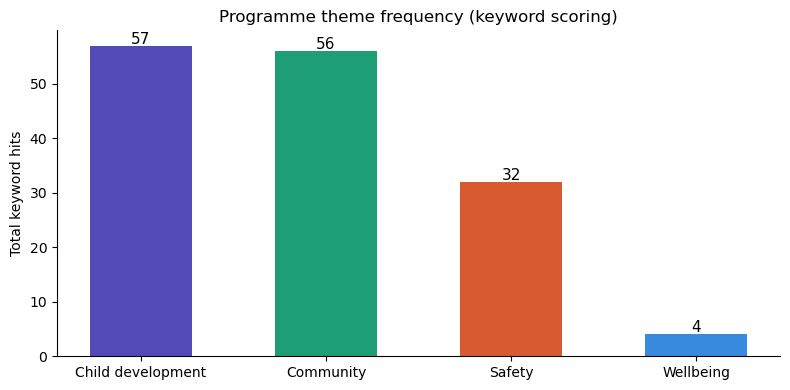

Saved theme_scores.png


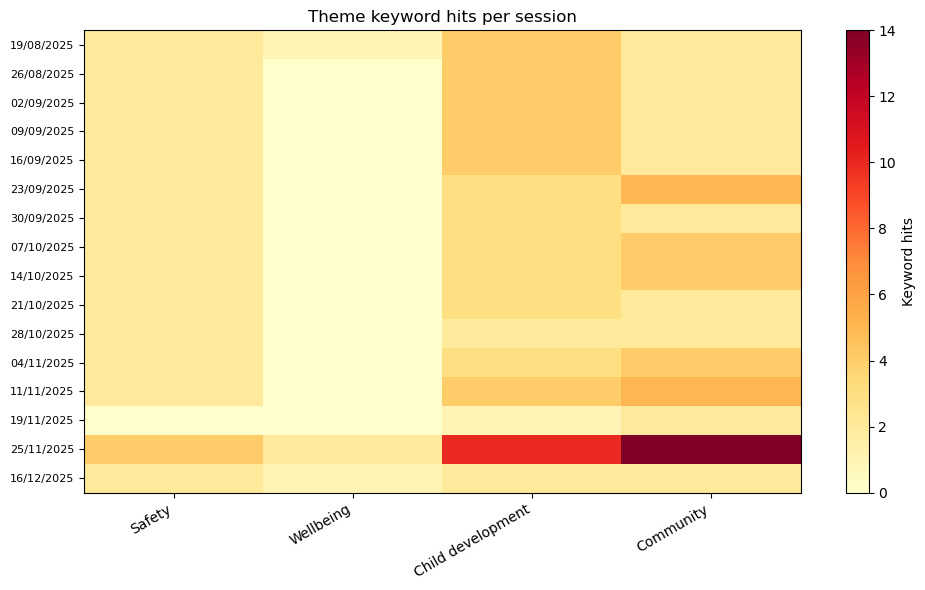

Saved theme_heatmap.png
Saved session_themes.csv


In [43]:
# ── Manual theme dictionary — keyword scoring & visualisation ─────────────────
# Previously defined but never used. Now scores each theme against clean_text
# and produces: (a) a bar chart of whole-document hits, (b) a per-session heatmap.

themes = {
    'Safety':            ['safe', 'secure', 'protected', 'boundaries', 'supervise', 'oversight'],
    'Wellbeing':         ['wellbeing', 'mental', 'emotional', 'calm', 'support', 'happy', 'comfort'],
    'Child development': ['development', 'learning', 'growth', 'milestone', 'explore', 'interact', 'engage'],
    'Community':         ['connect', 'social', 'peer', 'together', 'community', 'chat', 'socialise'],
}

# (a) Whole-document scores
text_lower   = clean_text.lower()
theme_scores = {}
theme_hits   = {}
for theme, keywords in themes.items():
    hits  = {kw: text_lower.count(kw) for kw in keywords}
    theme_scores[theme] = sum(hits.values())
    theme_hits[theme]   = {k: v for k, v in hits.items() if v > 0}

print('=== Theme keyword scores (whole document) ===')
for theme, score in sorted(theme_scores.items(), key=lambda x: -x[1]):
    print(f'  {theme:<22} {score:>4} hits   keywords fired: {theme_hits[theme]}')

# Bar chart
theme_colours = ['#534AB7', '#1D9E75', '#D85A30', '#378ADD']
sorted_t = sorted(theme_scores.items(), key=lambda x: -x[1])
t_labels = [t for t, _ in sorted_t]
t_values = [v for _, v in sorted_t]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(t_labels, t_values, color=theme_colours[:len(t_labels)], width=0.55)
for bar, val in zip(bars, t_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            str(val), ha='center', fontsize=11)
ax.set_title('Programme theme frequency (keyword scoring)', fontsize=12)
ax.set_ylabel('Total keyword hits')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('theme_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved theme_scores.png')

# (b) Per-session heatmap
heatmap_records = []
for s in sessions:   # sessions defined in per-session sentiment cell
    sl  = s['text'].lower()
    row = {'date': s['date']}
    for theme, keywords in themes.items():
        row[theme] = sum(sl.count(kw) for kw in keywords)
    heatmap_records.append(row)

heatmap_df = pd.DataFrame(heatmap_records).set_index('date')

fig, ax = plt.subplots(figsize=(10, max(6, len(heatmap_df) * 0.35)))
im = ax.imshow(heatmap_df.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=8)
ax.set_title('Theme keyword hits per session', fontsize=12)
plt.colorbar(im, ax=ax, label='Keyword hits')
plt.tight_layout()
plt.savefig('theme_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved theme_heatmap.png')

heatmap_df.to_csv('session_themes.csv')
print('Saved session_themes.csv')


## Keyword extraction — KeyBERT
KeyBERT uses sentence-transformer embeddings to extract keyphrases that are *semantically* most representative of the text — not just the most frequent words. Produces richer, more contextually meaningful output than word frequency alone.

In [44]:
from keybert import KeyBERT

# Initialise — downloads 'all-MiniLM-L6-v2' (~90 MB) on first run
kw_model = KeyBERT()

# 1. Whole-document keyphrases
doc_keywords = kw_model.extract_keywords(
    clean_text,
    keyphrase_ngram_range=(1, 3),
    stop_words='english',
    top_n=20,
    use_mmr=True,
    diversity=0.5,
)

print('=== Top 20 keyphrases (whole document) ===')
for phrase, score in doc_keywords:
    print(f'  {score:.3f}  {phrase}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

=== Top 20 keyphrases (whole document) ===
  0.631  play session parents
  0.614  toys arranged stay
  0.581  time session nursery
  0.557  playful movements nursery
  0.554  children continued play
  0.531  variety play activities
  0.524  continued playing supervision
  0.509  weekly stay play
  0.491  sing play
  0.478  storytelling activities coordinators
  0.412  enjoyed interacting
  0.363  rhyme storytelling
  0.355  played background event
  0.337  lunchtime prepared
  0.325  programme planning
  0.303  chat connect keeping
  0.301  break celebrated festive
  0.290  sleep danced
  0.272  venue cleaning setting
  0.070  donation basis support


In [45]:
# 2. Per-session top 5 keyphrases
try:
    _ = sessions[0]
except (NameError, IndexError):
    raise RuntimeError('Run the per-session sentiment parse cell first to define `sessions`.')

session_kw_records = []
for s in sessions:
    kws = kw_model.extract_keywords(
        s['text'],
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=5,
        use_mmr=True,
        diversity=0.4,
    )
    session_kw_records.append({
        'date':     s['date'],
        'keywords': ', '.join(f'{p} ({sc:.2f})' for p, sc in kws),
    })

kw_df = pd.DataFrame(session_kw_records)
print('=== Per-session top keyphrases ===')
print(kw_df.to_string(index=False))
kw_df.to_csv('session_keywords.csv', index=False)
print('\nSaved session_keywords.csv')


=== Per-session top keyphrases ===
      date                                                                                                                           keywords
19/08/2025                    play parental (0.52), toys session (0.50), rhyme time (0.43), prepared venue (0.39), coordinator anthony (0.38)
26/08/2025                       toys anthony (0.54), nursery rhyme (0.49), sing play (0.44), prepared venue (0.43), children enjoying (0.43)
02/09/2025               anthony prepared (0.50), nursery rhyme (0.46), potatoes lunch (0.45), children enjoying (0.40), served jackie (0.39)
09/09/2025                  nursery rhyme (0.55), toys event (0.50), play interact (0.42), session parents (0.41), coordinator anthony (0.39)
16/09/2025                     nursery rhyme (0.51), anthony prepared (0.49), music played (0.43), interacted toys (0.41), pizza lunch (0.40)
23/09/2025                lunch parents (0.54), anthony prepared (0.48), served toasted (0.45), interacted toys (

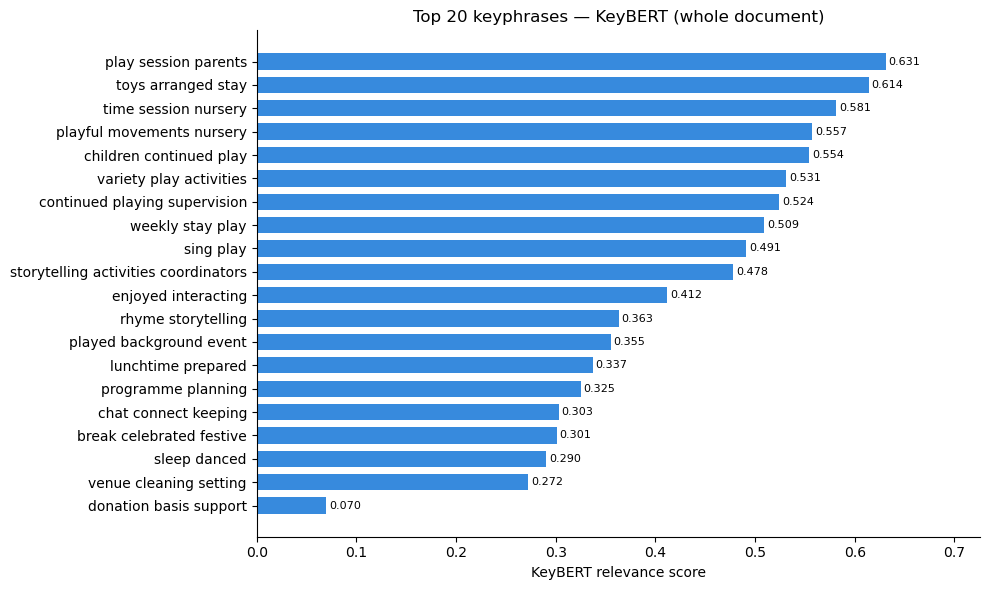

Saved keybert_keywords.png


In [46]:
# 3. Whole-document keyphrase bar chart
kw_labels = [p for p, _ in doc_keywords]
kw_scores = [round(s, 3) for _, s in doc_keywords]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(kw_labels[::-1], kw_scores[::-1], color='#378ADD', height=0.7)
for i, val in enumerate(kw_scores[::-1]):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('KeyBERT relevance score')
ax.set_title('Top 20 keyphrases — KeyBERT (whole document)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(kw_scores) * 1.15)
plt.tight_layout()
plt.savefig('keybert_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved keybert_keywords.png')


automatically discover recurring themes across all session summaries 

In [47]:
from docx import Document
import re
from nltk.corpus import stopwords

# ── Use the date-grouped `sessions` list (built in the session builder cell) ──
# This ensures raw_sessions, cleaned_sessions, and results_df all have the
# same number of rows as `sessions` (one per dated session, not one per paragraph).
# The master table join on 'date' then works correctly.

stop_words = set(stopwords.words('english'))
custom_stops = {'session', 'week', 'play', 'stay', 'children', 'parents', 'said', 'also'}
stop_words.update(custom_stops)

def clean_for_lda(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# raw_sessions: one full session text per date entry
raw_sessions     = [s['text'] for s in sessions]
cleaned_sessions = [clean_for_lda(s) for s in raw_sessions]

print(f'Total dated sessions for LDA: {len(cleaned_sessions)}')
print(f'Date range: {sessions[0]["date"]} → {sessions[-1]["date"]}')
print(f'\nFirst session preview (cleaned):')
print(cleaned_sessions[0][:200])


Total dated sessions for LDA: 16
Date range: 19/08/2025 → 16/12/2025

First session preview (cleaned):
coordinator anthony prepared venue cleaning space arranging toys opening arrived engaged parental supervision explored interacted toys opportunity chat connect keeping close eye little ones nursery rh


In [48]:
vectorizer = CountVectorizer(
    max_df=0.9,      # ignore words in more than 90% of docs (too common)
    min_df=2,        # ignore words in fewer than 2 docs (too rare)
    max_features=500 # keep only top 500 words by frequency
)

dtm = vectorizer.fit_transform(cleaned_sessions)
print(f"Matrix shape: {dtm.shape}")
# e.g. (42, 500) means 42 session entries × 500 unique words


Matrix shape: (16, 118)


Matrix shape: (42, 500) Each row = one session summary Each column = one word Each cell = word count in that session


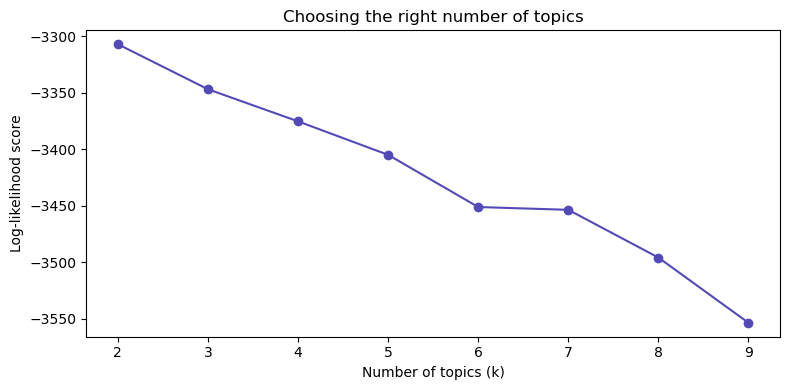

In [49]:
scores = []
k_range = range(2, 10)

for k in k_range:
    lda = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=20)
    lda.fit(dtm)
    scores.append(lda.score(dtm))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), scores, marker='o', color='#534AB7')
plt.xlabel('Number of topics (k)')
plt.ylabel('Log-likelihood score')
plt.title('Choosing the right number of topics')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('lda_k_selection.png', dpi=150)
plt.show()


In [50]:
N_TOPICS = 5  # change based on your elbow chart

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=50,
    learning_method='batch'
)

lda_model.fit(dtm)
print("Model trained successfully")


Model trained successfully


In [51]:
feature_names = vectorizer.get_feature_names_out()
n_top_words = 10

topic_labels = {}  # you'll fill these in after reading

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
    print(f"\nTopic {topic_idx + 1}:")
    print(' | '.join(top_words))



Topic 1:
support | including | singalong | offering | meal | toasted | bread | everyone | shared | setting

Topic 2:
prepared | coordinator | lunch | little | ones | throughout | event | explored | keeping | eye

Topic 3:
diane | concluded | arranging | began | variety | mums | preparing | area | chatted | connected

Topic 4:
continued | lunch | enjoyed | sarah | nursery | coordinator | concluded | preparing | area | rhymes

Topic 5:
tickets | toasted | bread | jungle | adventure | day | allowing | explore | featuring | along


In [52]:
topic_labels = {
    0: "Emotional Wellbeing",
    1: "Child Development",
    2: "Community Building",
    3: "Safe Environment",
    4: "Creative Engagement"
}

doc_topics = lda_model.transform(dtm)
dominant_topic = np.argmax(doc_topics, axis=1)

results_df = pd.DataFrame({
    'session_text': raw_sessions,
    'dominant_topic': dominant_topic,
    'topic_label': [topic_labels[t] for t in dominant_topic],
    'confidence': np.max(doc_topics, axis=1).round(2)
})

print(results_df[['topic_label', 'confidence']].head(10))
results_df.to_csv('session_topics.csv', index=False)


         topic_label  confidence
0  Child Development        0.98
1  Child Development        0.98
2  Child Development        0.98
3  Child Development        0.97
4  Child Development        0.98
5  Child Development        0.98
6  Child Development        0.98
7  Child Development        0.57
8   Safe Environment        0.98
9  Child Development        0.97


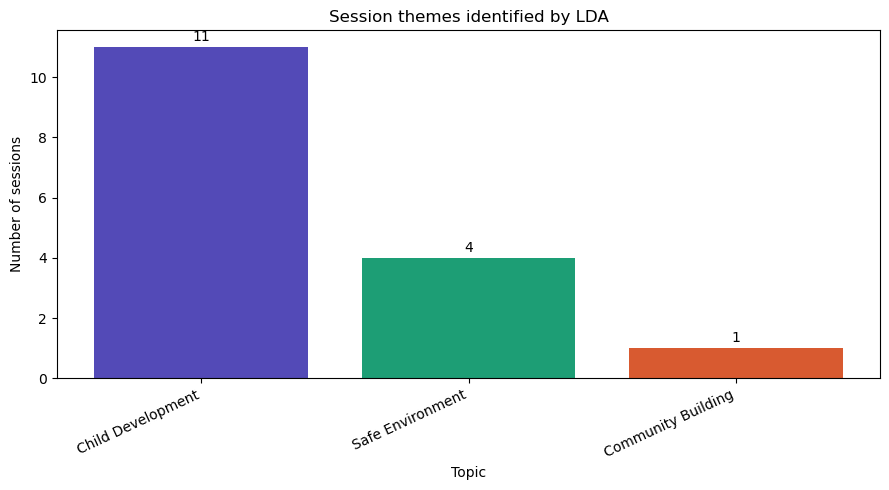

Saved lda_topics.html — open in browser for interactive chart


In [53]:
# Bar chart — how many sessions per topic
topic_counts = results_df['topic_label'].value_counts()
colors = ['#534AB7','#1D9E75','#D85A30','#378ADD','#BA7517']

plt.figure(figsize=(9, 5))
bars = plt.bar(topic_counts.index, topic_counts.values, color=colors)
plt.title('Session themes identified by LDA')
plt.xlabel('Topic')
plt.ylabel('Number of sessions')
plt.xticks(rotation=25, ha='right')
for bar, val in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150)
plt.show()

# Interactive pyLDAvis chart — opens in browser
vis = pyLDAvis.lda_model.prepare(lda_model, dtm, vectorizer)
pyLDAvis.save_html(vis, 'lda_topics.html')
print("Saved lda_topics.html — open in browser for interactive chart")


## Per-session master table
Joins all session-level results — LDA topic, sentiment polarity, tone and KeyBERT keyphrases — into one DataFrame keyed on session date. Exported as `session_master.csv` for use in reports and the Stay & Play dashboard.

In [54]:
# ── Per-session master table ─────────────────────────────────────────────────
# results_df rows align 1-to-1 with `sessions` (both built from date-grouped corpus).
# We attach the date from sessions directly — no re-parse needed.

lda_dated = results_df.copy()
lda_dated['date'] = [s['date'] for s in sessions]   # direct 1-to-1 alignment

# Merge LDA topics + per-session sentiment + KeyBERT keywords
master_df = (
    lda_dated[['date', 'topic_label', 'confidence']]
    .merge(sentiment_df[['date', 'polarity', 'subjectivity', 'tone']], on='date', how='left')
    .merge(kw_df[['date', 'keywords']], on='date', how='left')
)
master_df['date_parsed'] = pd.to_datetime(master_df['date'], dayfirst=True, errors='coerce')
master_df = master_df.sort_values('date_parsed').reset_index(drop=True)

print('=== Per-session master table ===')
print(master_df[['date', 'topic_label', 'confidence', 'polarity', 'tone', 'keywords']]
      .to_string(index=False))

master_df.drop(columns='date_parsed').to_csv('session_master.csv', index=False)
print('\nSaved session_master.csv')


=== Per-session master table ===
      date        topic_label  confidence  polarity     tone                                                                                                                           keywords
19/08/2025  Child Development        0.98     0.303 Positive                    play parental (0.52), toys session (0.50), rhyme time (0.43), prepared venue (0.39), coordinator anthony (0.38)
26/08/2025  Child Development        0.98     0.303 Positive                       toys anthony (0.54), nursery rhyme (0.49), sing play (0.44), prepared venue (0.43), children enjoying (0.43)
02/09/2025  Child Development        0.98     0.303 Positive               anthony prepared (0.50), nursery rhyme (0.46), potatoes lunch (0.45), children enjoying (0.40), served jackie (0.39)
09/09/2025  Child Development        0.97     0.238 Positive                  nursery rhyme (0.55), toys event (0.50), play interact (0.42), session parents (0.41), coordinator anthony (0.39)
16/09/2

## Time-series trend analysis
Three-panel chart — sentiment polarity, LDA topic confidence, and adjective density — across the Aug 2025 – May 2026 programme period. Rolling averages smooth session-to-session noise so structural trends stand out.

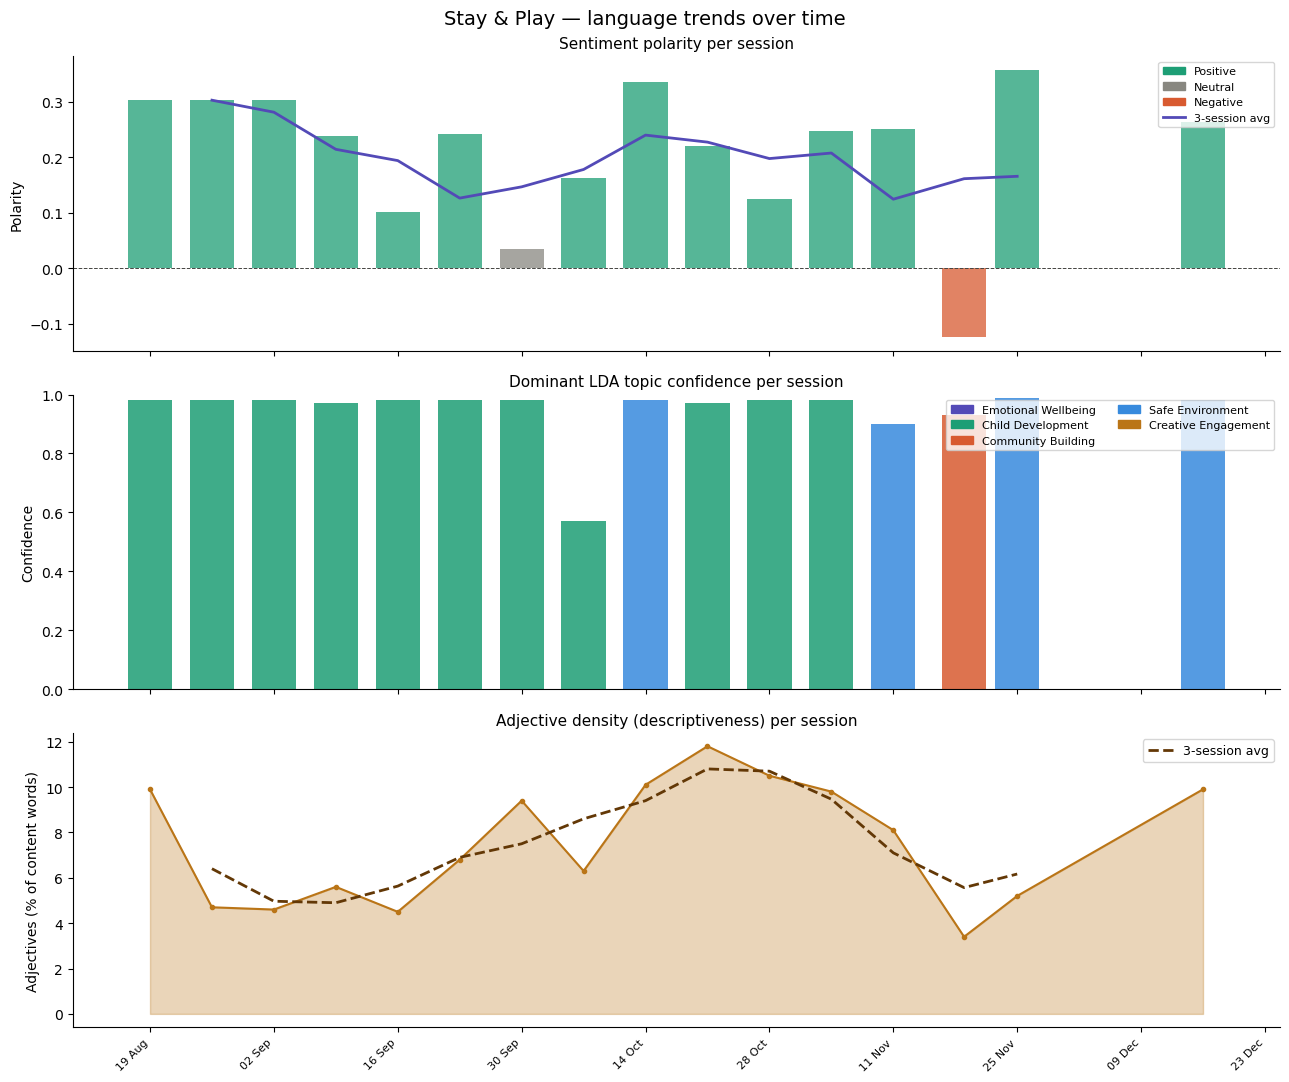

Saved time_series_trends.png


In [55]:
trend_df = master_df.copy()
trend_df['date_parsed'] = pd.to_datetime(trend_df['date'], dayfirst=True, errors='coerce')

try:
    trend_df = trend_df.merge(pos_profile_df[['date', 'adj_pct']], on='date', how='left')
except NameError:
    trend_df['adj_pct'] = float('nan')   # run POS per-session cell to enable this panel

TONE_C  = {'Positive': '#1D9E75', 'Neutral': '#888780', 'Negative': '#D85A30'}
TOPIC_C = {
    'Emotional Wellbeing':  '#534AB7',
    'Child Development':    '#1D9E75',
    'Community Building':   '#D85A30',
    'Safe Environment':     '#378ADD',
    'Creative Engagement':  '#BA7517',
}
W = 3
dates = trend_df['date_parsed']

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle('Stay & Play — language trends over time', fontsize=14)

# Panel 1 — sentiment polarity
ax1 = axes[0]
ax1.bar(dates, trend_df['polarity'], color=trend_df['tone'].map(TONE_C).fillna('#888780'),
        width=5, alpha=0.75)
ax1.plot(dates, trend_df['polarity'].rolling(W, center=True).mean(),
         color='#534AB7', linewidth=2, label=f'{W}-session rolling avg')
ax1.axhline(0, color='#444441', linewidth=0.7, linestyle='--')
ax1.set_ylabel('Polarity')
ax1.set_title('Sentiment polarity per session', fontsize=11)
ax1.legend(
    handles=[Patch(color=c, label=t) for t, c in TONE_C.items()] +
             [plt.Line2D([0],[0], color='#534AB7', linewidth=2, label=f'{W}-session avg')],
    fontsize=8, loc='upper right'
)
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2 — LDA topic confidence
ax2 = axes[1]
ax2.bar(dates, trend_df['confidence'],
        color=trend_df['topic_label'].map(TOPIC_C).fillna('#888780'), width=5, alpha=0.85)
ax2.set_ylabel('Confidence')
ax2.set_ylim(0, 1)
ax2.set_title('Dominant LDA topic confidence per session', fontsize=11)
ax2.legend(handles=[Patch(color=c, label=t) for t, c in TOPIC_C.items()],
           fontsize=8, ncol=2, loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)

# Panel 3 — adjective density
ax3 = axes[2]
if trend_df['adj_pct'].notna().any():
    ax3.fill_between(dates, trend_df['adj_pct'], alpha=0.3, color='#BA7517')
    ax3.plot(dates, trend_df['adj_pct'], color='#BA7517', linewidth=1.5,
             marker='o', markersize=3)
    ax3.plot(dates, trend_df['adj_pct'].rolling(W, center=True).mean(),
             color='#633806', linewidth=2, linestyle='--', label=f'{W}-session avg')
    ax3.set_ylabel('Adjectives (% of content words)')
    ax3.legend(fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Run POS per-session cell to populate this panel',
             ha='center', va='center', transform=ax3.transAxes, fontsize=10, color='#888780')
ax3.set_title('Adjective density (descriptiveness) per session', fontsize=11)
ax3.spines[['top', 'right']].set_visible(False)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('time_series_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved time_series_trends.png')
